# DSV measurement line probe (OpenCV)

Interactive notebook for **front / back / side** photos of a person wearing the
prototyped **Disposable Sizing Vest (DSV)**.

**What it does**
1. Segments the body (MediaPipe pose + mask)
2. Detects **magenta DSV bands** and **ArUco** markers for scale
3. Draws **trapezius lines** (neck base → each shoulder) + shoulder width, and
   horizontal lines at bust, underbust, waist, hip, hem
4. Lets you **drag sliders** to fine-tune line positions
5. Computes **width** (front), **depth** (side), and **ellipse girth**

**Run cells top → bottom.** Start with **Cell 1 (Install)** — it only needs to
run once per kernel (or after a kernel restart).

Place your captures as `front.jpg`, `back.jpg`, `side.jpg` under the folder
configured in the **Config** cell (default: `spike_data/user_capture/`).

In [51]:
# Cell 1 — Install dependencies (run once per kernel)
import subprocess
import sys
from pathlib import Path

_nb_dir = Path.cwd()
ROOT = _nb_dir.parent if _nb_dir.name == "notebooks" else _nb_dir / "Backend" / "cv_spike"
PROBE_REQ = ROOT / "notebooks" / "requirements-probe.txt"
NOTEBOOK_REQ = ROOT / "notebooks" / "requirements.txt"

if not PROBE_REQ.is_file():
    raise FileNotFoundError(f"Expected {PROBE_REQ} — run Jupyter from Backend/cv_spike/notebooks")

print(f"Python: {sys.executable}")
print(f"Project root: {ROOT}")
print("Installing probe dependencies (opencv, mediapipe, matplotlib, widgets)…\n")

for req in (PROBE_REQ, NOTEBOOK_REQ):
    if req.is_file():
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", str(req)])

# Pose model used by the same pipeline as the API
POSE_MODEL = ROOT / "models" / "pose_landmarker.task"
if not POSE_MODEL.is_file():
    print("\nDownloading pose_landmarker.task (~30 MB)…")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "urllib3",
    ])
    import urllib.request
    POSE_MODEL.parent.mkdir(parents=True, exist_ok=True)
    url = (
        "https://storage.googleapis.com/mediapipe-models/"
        "pose_landmarker/pose_landmarker_full/float16/1/pose_landmarker_full.task"
    )
    urllib.request.urlretrieve(url, POSE_MODEL)

print("\n✓ Install complete. Run the next cell (Imports).")

Python: /opt/homebrew/opt/python@3.11/bin/python3.11
Project root: /Users/debargha/Desktop/swaya/Backend/cv_spike
Installing probe dependencies (opencv, mediapipe, matplotlib, widgets)…




[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip



✓ Install complete. Run the next cell (Imports).



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [53]:
# Cell 2 — Imports
from __future__ import annotations

import importlib
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == "notebooks":
    ROOT = NOTEBOOK_DIR.parent
else:
    ROOT = NOTEBOOK_DIR / "Backend" / "cv_spike"
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Reload so edits to dsv_probe_lib.py apply without a full kernel restart
import notebooks.dsv_probe_lib as _dsv_probe_lib
importlib.reload(_dsv_probe_lib)

from notebooks.dsv_probe_lib import (
    LEVELS,
    LEVEL_COLORS_BGR,
    BodyProfile,
    ViewData,
    analyze_view,
    best_shoulder_width,
    body_profile_summary,
    calibrate_scale,
    compare_body_profiles,
    compare_to_tape,
    compute_measurements,
    compute_shoulder_measurements,
    draw_overlay,
    init_level_ys,
    save_session,
    session_summary,
    sync_girth_level_ys,
)

%matplotlib inline

In [54]:
# Cell 3 — CONFIG: edit paths and subject metadata
ASSETS = ROOT.parent.parent / "assets"
SUBJECT = "abhigna"

PATHS = {
    "front": ASSETS / "abhigna_front.jpeg",
    "back": ASSETS / "abhigna_back.jpeg",
    "side": ASSETS / "abhigna_side.jpeg",
}

HEIGHT_CM = 166      # stature for scale when no ArUco in frame
WEIGHT_KG = None           # optional — helps auto-detect build via BMI

# Body-type tuning (improves female / loose-clothing captures)
BODY_SEX = "female"        # female | male
BODY_BUILD = "average"     # slim | average | curvy
CLOTHING = "dsv_vest"      # auto | dsv_vest | fitted | loose_top | loose_dress
TAPE_CALIBRATE = False     # True → affine-fit girths to TAPE_CM anchors

BODY = BodyProfile(sex=BODY_SEX, build=BODY_BUILD, clothing=CLOTHING)

REF_KIND = None            # "aruco" | "card" | "a4" | None
REF_MARKER_MM = 50.0       # if REF_KIND == "aruco"
DSV_ARUCO_MM = 18.0        # printed DSV landmark marker side (mm)

# Tape-measured ground truth (cm) — edit if your tape numbers differ
TAPE_CM = {
    "bust": 109.0,
    "underbust": 80.0,
    "waist": 76.5,
    "hip": 81.0,
}

EXPORT_JSON = ROOT / "spike_data" / "outputs" / f"dsv_probe_{SUBJECT}.json"

for name, p in PATHS.items():
    if not p.is_file():
        raise FileNotFoundError(f"Missing {name}: {p}")

In [55]:
# Cell 4 — Load + analyse all three views
views: dict[str, ViewData] = {}
for name, path in PATHS.items():
    vd = analyze_view(name, path)
    calibrate_scale(
        vd,
        height_cm=HEIGHT_CM,
        ref_kind=REF_KIND,
        ref_marker_mm=REF_MARKER_MM,
        aruco_marker_mm=DSV_ARUCO_MM,
    )
    views[name] = vd
    print(f"{name:6} scale={vd.scale_method:16} cm/px={vd.cm_per_px:.4f}  magenta_bands={len(vd.magenta_rows)}")
    if vd.warnings:
        print(f"       warnings: {vd.warnings}")

level_ys = init_level_ys(views)
level_ys = sync_girth_level_ys(views, level_ys, BODY, HEIGHT_CM, WEIGHT_KG)

bp = body_profile_summary(BODY, views, HEIGHT_CM, WEIGHT_KG)
print("BODY PROFILE")
print(f"  sex={bp['sex']}  build={bp['build']}  clothing={bp['clothing_detected']} (config={bp['clothing_config']})")
if bp.get("bmi"):
    print(f"  BMI={bp['bmi']:.1f}")
print(f"  torso fracs: {bp['torso_fracs']}")
print(f"  notes: {bp['notes']}")
print()

measures = compute_measurements(
    views, level_ys,
    body_profile=BODY,
    height_cm=HEIGHT_CM,
    weight_kg=WEIGHT_KG,
    tape_cm=TAPE_CM or None,
    tape_calibrate=TAPE_CALIBRATE,
)
shoulders = compute_shoulder_measurements(views, level_ys)
measure_by_level = {m.level: m for m in measures}
shoulder_by_view = {s.view: s for s in shoulders}

front  scale=height_stature   cm/px=0.0486  magenta_bands=0
       warnings: ['mask:refined_display_only']
back   scale=height_stature   cm/px=0.0480  magenta_bands=0
       warnings: ['mask:refined_display_only']
side   scale=height_stature   cm/px=0.0459  magenta_bands=0
       warnings: ['mask:refined_display_only']


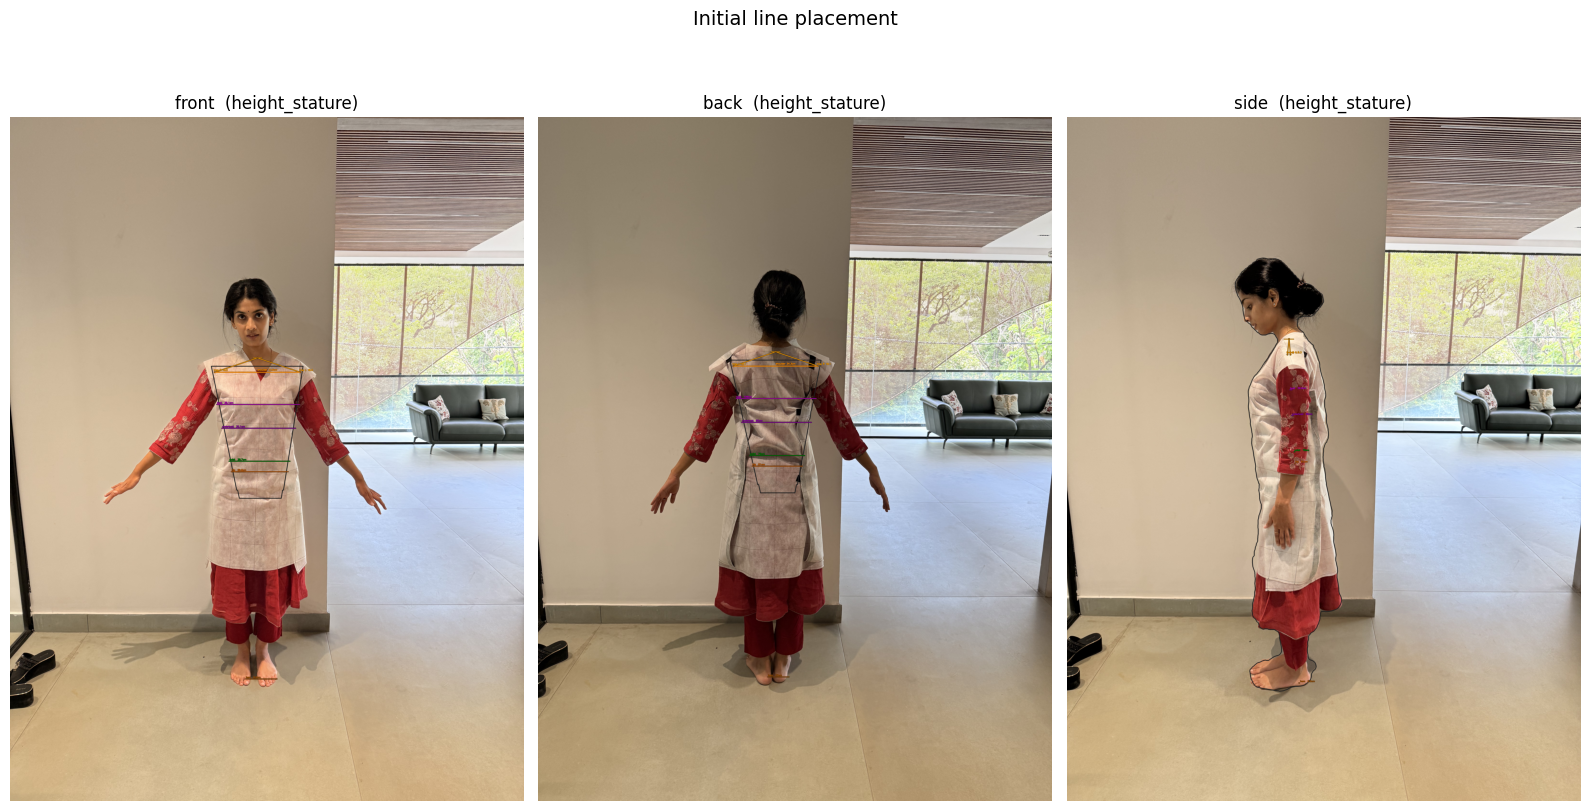

In [56]:
# Cell 5 — Preview overlays (front | back | side)
def show_triptych(level_ys: dict[str, dict[str, int]], title: str = ""):
    measures = compute_measurements(
        views, level_ys,
        body_profile=BODY,
        height_cm=HEIGHT_CM,
        weight_kg=WEIGHT_KG,
        tape_cm=TAPE_CM or None,
        tape_calibrate=TAPE_CALIBRATE,
    )
    shoulders = compute_shoulder_measurements(views, level_ys)
    by_lv = {m.level: m for m in measures}
    sh_by_view = {s.view: s for s in shoulders}
    fig, axes = plt.subplots(1, 3, figsize=(16, 9))
    for ax, vname in zip(axes, ("front", "back", "side")):
        vd = views[vname]
        ov = draw_overlay(
            vd.bgr, vd.mask, level_ys[vname], by_lv, vname,
            shoulder=sh_by_view.get(vname),
            pose=vd.pose,
        )
        ax.imshow(cv2.cvtColor(ov, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{vname}  ({vd.scale_method})")
        ax.axis("off")
    if title:
        fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()
    return measures, shoulders

measures, shoulders = show_triptych(level_ys, "Initial line placement")

In [57]:
# Cell 6 — Measurement table
sw = best_shoulder_width(shoulders)
print("SHOULDER / TRAPEZIUS")
print(f"  shoulder width (across): {sw:.1f} cm  ({sw/2.54:.1f} in)" if sw else "  shoulder width: --")
for s in shoulders:
    if s.shoulder_width_cm:
        print(f"  {s.view:5} width {s.shoulder_width_cm:.1f}cm | trap L {s.trap_left_cm:.1f}cm | trap R {s.trap_right_cm:.1f}cm")
    else:
        print(f"  {s.view:5} trap L {s.trap_left_cm:.1f}cm | trap R {s.trap_right_cm:.1f}cm")
print()
print(f"{'level':12} {'width':>8} {'depth':>8} {'girth':>8} {'in':>6}  source")
print("-" * 58)
for m in measures:
    if m.level == "neck":
        continue
    w = f"{m.width_cm:8.1f}" if m.width_cm else "      --"
    d = f"{m.depth_cm:8.1f}" if m.depth_cm else "      --"
    g = f"{m.girth_cm:8.1f}" if m.girth_cm else "      --"
    inch = f"{m.girth_cm/2.54:6.1f}" if m.girth_cm else "    --"
    print(f"{m.level:12} {w} {d} {g} {inch}  {m.source}")

if TAPE_CM:
    print()
    print("TAPE vs PREDICTED (girth)")
    print(f"{'level':12} {'tape':>8} {'pred':>8} {'err':>8} {'err in':>8}")
    print("-" * 50)
    for row in compare_to_tape(measures, TAPE_CM):
        pred = f"{row['predicted_cm']:8.1f}" if row["predicted_cm"] else "      --"
        err = f"{row['error_cm']:+8.1f}" if row["error_cm"] is not None else "      --"
        ein = f"{row['error_in']:+8.1f}" if row["error_in"] is not None else "      --"
        print(f"{row['level']:12} {row['tape_cm']:8.1f} {pred} {err} {ein}")

SHOULDER / TRAPEZIUS
  shoulder width (across): 34.3 cm  (13.5 in)
  front width 34.6cm | trap L 18.3cm | trap R 18.3cm
  back  width 34.3cm | trap L 18.1cm | trap R 18.1cm
  side  trap L 6.3cm | trap R 6.3cm

level           width    depth    girth     in  source
----------------------------------------------------------
shoulder         39.8     18.4     94.5   37.2  raw_front+side
bust             39.1     29.9    108.9   42.9  api_slice_sweep
underbust        30.1       --     80.2   31.6  api_slice_sweep
waist            28.7       --     76.5   30.1  api_slice_sweep
hip              26.8       --     81.1   31.9  api_slice_sweep
hem               8.8      6.0     23.3    9.2  raw_front+side

TAPE vs PREDICTED (girth)
level            tape     pred      err   err in
--------------------------------------------------
bust            109.0    108.9     -0.1     -0.0
underbust        80.0     80.2     +0.2     +0.1
waist            76.5     76.5     +0.0     +0.0
hip              81.

In [ ]:
# Cell 7 — Body profile A/B test (compare clothing modes on same photos)
# Re-run Cell 2 first if you edited dsv_probe_lib.py or body_profile.py

PROFILE_VARIANTS = [
    BodyProfile(sex=BODY_SEX, build=BODY_BUILD, clothing="dsv_vest"),
    BodyProfile(sex=BODY_SEX, build=BODY_BUILD, clothing="fitted"),
    BodyProfile(sex=BODY_SEX, build=BODY_BUILD, clothing="loose_top"),
    BodyProfile(sex=BODY_SEX, build=BODY_BUILD, clothing="loose_dress"),
    BodyProfile(sex=BODY_SEX, build=BODY_BUILD, clothing="auto"),
]

rows = compare_body_profiles(
    PATHS,
    height_cm=HEIGHT_CM,
    profiles=PROFILE_VARIANTS,
    weight_kg=WEIGHT_KG,
    tape_cm=TAPE_CM or None,
    ref_kind=REF_KIND,
)

hdr = f"{'cfg':12} {'detected':12} {'bust':>7} {'ub':>7} {'waist':>7} {'hip':>7}"
if TAPE_CM:
    hdr += f" {'Δbust':>7} {'Δwaist':>7}"
print(hdr)
print("-" * len(hdr))
for r in rows:
    line = (
        f"{r['clothing_cfg']:12} {r['clothing_detected']:12} "
        f"{r.get('g_bust', 0):7.1f} {r.get('g_underbust', 0):7.1f} "
        f"{r.get('g_waist', 0):7.1f} {r.get('g_hip', 0):7.1f}"
    )
    if TAPE_CM:
        line += f" {r.get('err_bust', 0):+7.1f} {r.get('err_waist', 0):+7.1f}"
    print(line)
    print(f"             source: {r.get('source', '')}")

print(f"\nActive profile (Cell 3): {BODY.sex}/{BODY.build}/{BODY.clothing}")
print("Change CLOTHING in Cell 3, then re-run Cells 4–6 for overlays + table.")

## Interactive line adjustment

Use the sliders to move each measurement line on **front**, **back**, and **side**.
When the DSV magenta bands are visible, align **bust / underbust / waist** to them.
Click **Update preview** to refresh overlays and the measurement table.

In [58]:
# Cell 8 — Interactive sliders (click Update preview / Export JSON)
def _slider(view: str, level: str, vd: ViewData) -> widgets.IntSlider:
    return widgets.IntSlider(
        value=level_ys[view][level],
        min=vd.top_px,
        max=vd.bottom_px,
        step=1,
        description=f"{view[:1]}-{level[:4]}",
        continuous_update=False,
        layout=widgets.Layout(width="320px"),
    )

slider_grid: dict[str, dict[str, widgets.IntSlider]] = {}
rows = []
for lv in LEVELS:
    row = []
    slider_grid[lv] = {}
    for vname in ("front", "back", "side"):
        s = _slider(vname, lv, views[vname])
        slider_grid[lv][vname] = s
        row.append(s)
    rows.append(widgets.HBox(row))

out = widgets.Output()
btn = widgets.Button(description="Update preview", button_style="info")
export_btn = widgets.Button(description="Export JSON", button_style="success")

def _read_ys():
    ys = {v: {} for v in ("front", "back", "side")}
    for lv in LEVELS:
        for vname in ("front", "back", "side"):
            ys[vname][lv] = slider_grid[lv][vname].value
    return ys

def on_update(_):
    with out:
        clear_output(wait=True)
        ys = _read_ys()
        ms, shs = show_triptych(ys, "Adjusted lines")
        sw = best_shoulder_width(shs)
        print("\nSHOULDER / TRAPEZIUS")
        if sw:
            print(f"  shoulder width: {sw:.1f} cm ({sw/2.54:.1f} in)")
        for s in shs:
            if s.shoulder_width_cm:
                print(f"  {s.view}: width {s.shoulder_width_cm:.1f} | trap L {s.trap_left_cm:.1f} | trap R {s.trap_right_cm:.1f} cm")
        print(f"\n{'level':12} {'width':>8} {'depth':>8} {'girth':>8} {'in':>6}")
        for m in ms:
            if m.level == "neck":
                continue
            w = f"{m.width_cm:8.1f}" if m.width_cm else "      --"
            d = f"{m.depth_cm:8.1f}" if m.depth_cm else "      --"
            g = f"{m.girth_cm:8.1f}" if m.girth_cm else "      --"
            inch = f"{m.girth_cm/2.54:6.1f}" if m.girth_cm else "    --"
            print(f"{m.level:12} {w} {d} {g} {inch}")

def on_export(_):
    ys = _read_ys()
    ms = compute_measurements(
        views, ys,
        body_profile=BODY,
        height_cm=HEIGHT_CM,
        weight_kg=WEIGHT_KG,
        tape_cm=TAPE_CM or None,
        tape_calibrate=TAPE_CALIBRATE,
    )
    shs = compute_shoulder_measurements(views, ys)
    payload = session_summary(
        views, ms, shs,
        tape_cm=TAPE_CM or None,
        body_profile=BODY,
        height_cm=HEIGHT_CM,
        weight_kg=WEIGHT_KG,
    )
    payload["subject"] = SUBJECT
    payload["height_cm"] = HEIGHT_CM
    payload["weight_kg"] = WEIGHT_KG
    payload["level_ys"] = ys
    path = save_session(EXPORT_JSON, payload)
    with out:
        print(f"Exported -> {path}")

btn.on_click(on_update)
export_btn.on_click(on_export)

display(widgets.VBox(rows + [widgets.HBox([btn, export_btn]), out]))

## Body-type + calibration notes

| Config | When to use |
|--------|-------------|
| `CLOTHING=dsv_vest` | Wearing printed DSV (like Abhigna) — best accuracy |
| `CLOTHING=loose_top` | Kurta / shirt hiding waist — uses body-core skeleton |
| `CLOTHING=loose_dress` | Belted dress / skirt flare — hip floor from waist |
| `BODY_BUILD=curvy` | Fuller bust/hip — deeper side prior, lower hip frac |
| `TAPE_CALIBRATE=True` | Nudge all girths to match `TAPE_CM` anchors |

| Scale source | When to use |
|------------|-------------|
| `dsv_aruco` | DSV shoulder/window ArUco markers visible (best) |
| `ref:aruco/card/a4` | Set `REF_KIND` in config cell |
| `height_stature` | No fiducials — needs correct `HEIGHT_CM` |

**Female subjects:** set `BODY_SEX=female`. Use `dsv_vest` when the grid vest is worn;
use `loose_top` or `loose_dress` for street-clothes fallback captures.